# Random Walk analysis


## Imports

In [10]:
#Imports 

import pandas as pd
import zipfile
import os
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from ucimlrepo import fetch_ucirepo 
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt


## Load Data

In [2]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df_original = bike_sharing.data.original

# Comprobamos que están todas
X = df_original.drop(["cnt","casual","registered"], axis = "columns")

y_casual = df_original["casual"]
y_registered = df_original["registered"]


In [3]:
print("y_casual..........")
print(y_casual.head(15))

print("y_registered..........")
print(y_registered.head(15))

y_casual..........
0      3
1      8
2      5
3      3
4      0
5      0
6      2
7      1
8      1
9      8
10    12
11    26
12    29
13    47
14    35
Name: casual, dtype: int64
y_registered..........
0     13
1     32
2     27
3     10
4      1
5      1
6      0
7      2
8      7
9      6
10    24
11    30
12    55
13    47
14    71
Name: registered, dtype: int64


## 1.We check if the time series are stationary (ADF test)

In [4]:
def adf_test(y):
    ADF_result = adfuller(y)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}') #if <0.05 stationary
    print(ADF_result)
  

In [ ]:
print("ADF CASUAL TEST..............")
adf_test(y_casual)

print("\nADF CASUAL TEST..............")
adf_test(y_registered)

#both stationary


ADF CASUAL TEST..............
ADF Statistic: -13.667510462615047
p-value: 1.4810353782019986e-25
(np.float64(-13.667510462615047), np.float64(1.4810353782019986e-25), 44, 17334, {'1%': np.float64(-3.430727308679485), '5%': np.float64(-2.861706755762842), '10%': np.float64(-2.566858759781439)}, np.float64(141786.07448611184))

ADF CASUAL TEST..............
ADF Statistic: -7.531837064367629
p-value: 3.561648678545711e-11
(np.float64(-7.531837064367629), np.float64(3.561648678545711e-11), 44, 17334, {'1%': np.float64(-3.430727308679485), '5%': np.float64(-2.861706755762842), '10%': np.float64(-2.566858759781439)}, np.float64(186838.72189114572))


## 2.We check if there is correlation (ACF plot)

We note that they are not trully stationary despite what the ADF test said

([<matplotlib.axis.XTick at 0x18948925bd0>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

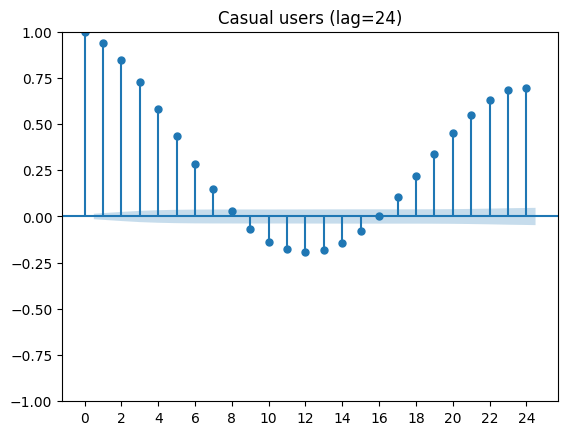

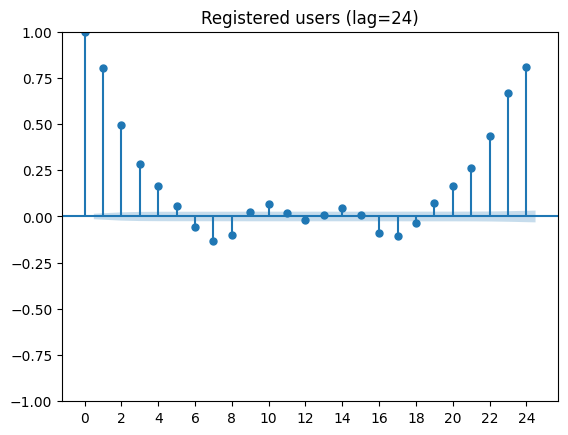

In [28]:
plot_acf(y_casual, lags=24, title="Casual users (lag=24)" )
plt.xticks(range(0, 26, 2)) 


plot_acf(y_registered, lags=24, title = "Registered users (lag=24)"); 
plt.xticks(range(0, 26, 2)) 

([<matplotlib.axis.XTick at 0x1894889b690>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24'),
  Text(26, 0, '26'),
  Text(28, 0, '28'),
  Text(30, 0, '30'),
  Text(32, 0, '32'),
  Text(34, 0, '34'),
  Text(36, 0, '36'),
  Text(38, 0, '38'),
  Text(40, 0, '40'),
  Text(42, 0, '42'),
  Text(44, 0, '44'),
  Text(46, 0, '46'),
  Text(48, 0, '48'),
  Text(50, 0, '50')])

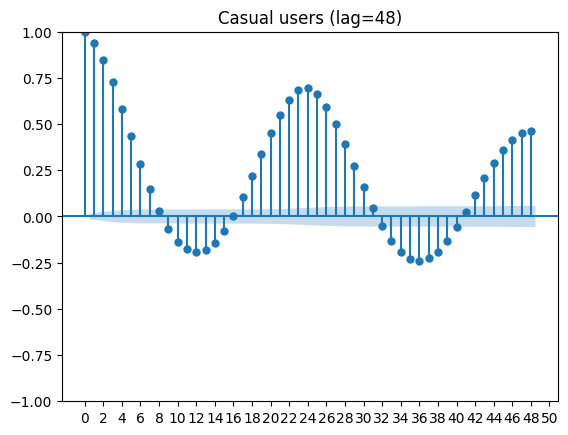

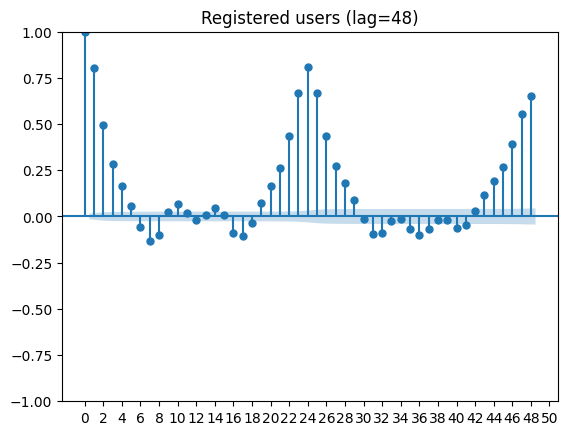

In [27]:
#Zoom out to 48 
plot_acf(y_casual, lags=48, title="Casual users (lag=48)")
plt.xticks(range(0, 52, 2)) 


plot_acf(y_registered, lags=48, title = "Registered users (lag=48)"); 
plt.xticks(range(0, 52, 2)) 

### We apply seasonal differentiation

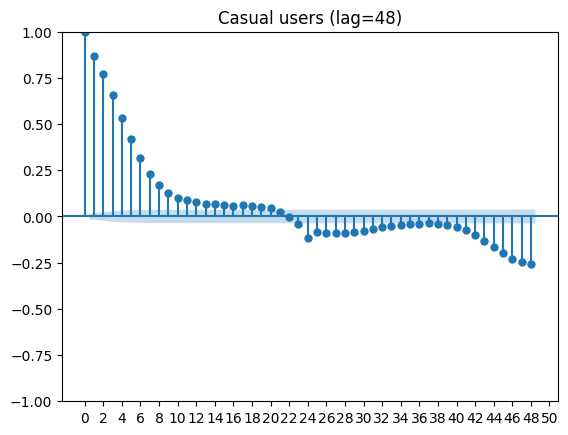

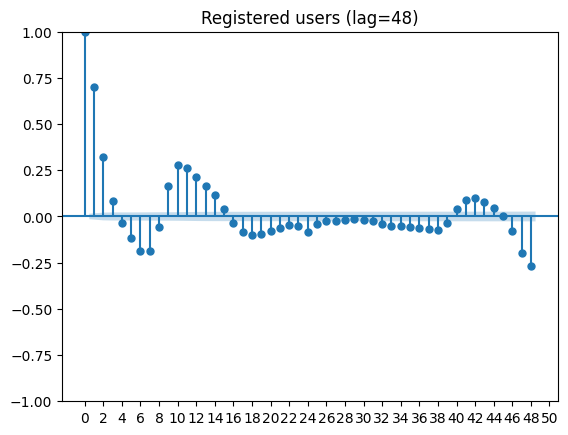

In [ ]:

y_casual_estacionario = y_casual.diff(periods=24).dropna()
plot_acf(y_casual_estacionario, lags=48, title="Casual users (lag=48)")
plt.xticks(range(0, 52, 2)) 
plt.show()



y_reg_estacionario = y_registered.diff(periods=24).dropna()
plot_acf(y_reg_estacionario, lags=48, title="Registered users (lag=48)")
plt.xticks(range(0, 52, 2)) 
plt.show()